In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use("default")
sns.set_theme(style="whitegrid")

FIGURE_PATH = "../../outputs/figures"
os.makedirs(FIGURE_PATH, exist_ok=True)

print("Figure output folder:", FIGURE_PATH)
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


Figure output folder: ../../outputs/figures


In [10]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_all_data
from src.data_cleaning import clean_data
from src.analysis import generate_kpi_summary

data = load_all_data()

customers = data["customers_medium"]
menu_items = data["menu_items"]
order_items = data["order_items (2)"]
orders = data["orders_medium"]
restaurants = data["restaurants"]

customers = clean_data(
    customers,
    datetime_columns=["signup_date"]
)

orders = clean_data(
    orders,
    datetime_columns=["order_time", "delivery_time"]
)

order_items["item_revenue"] = (
    order_items["quantity"] * order_items["price"]
)

orders["delivery_time_minutes"] = (
    orders["delivery_time"] - orders["order_time"]
).dt.total_seconds() / 60

In [12]:
from src.analysis import generate_kpi_summary

In [13]:
kpi_summary = generate_kpi_summary(
    customers,
    orders,
    restaurants,
    order_items
)

kpi_summary

,Metric,Value
0,Total Revenue,560509.15
1,Total Orders,5000.00
2,Total Customers,1500.00
3,Active Customers,1452.00
4,Total Restaurants,120.00
5,Total Items Sold,24699.00
6,Average Order Value,112.10
7,Repeat Customer Rate,87.60
8,Revenue per Active Customer,386.03
9,Average Items per Order,4.94


In [4]:
customer_segments = customer_order_counts.copy()

customer_segments["segment"] = np.select(
    [
        customer_segments["total_orders"] == 1,
        customer_segments["total_orders"].between(2, 4),
        customer_segments["total_orders"] >= 5
    ],
    [
        "One-Time",
        "Regular",
        "High-Frequency"
    ],
    default="Other"
)

segment_summary = (
    customer_segments
    .groupby("segment")
    .agg(
        customers=("customer_id", "nunique"),
        total_orders=("total_orders", "sum")
    )
    .reset_index()
)

segment_summary["order_share_pct"] = (
    segment_summary["total_orders"]
    / segment_summary["total_orders"].sum() * 100
)

segment_summary


,segment,customers,total_orders,order_share_pct
0,High-Frequency,367,2146,42.92
1,One-Time,180,180,3.60
2,Regular,905,2674,53.48


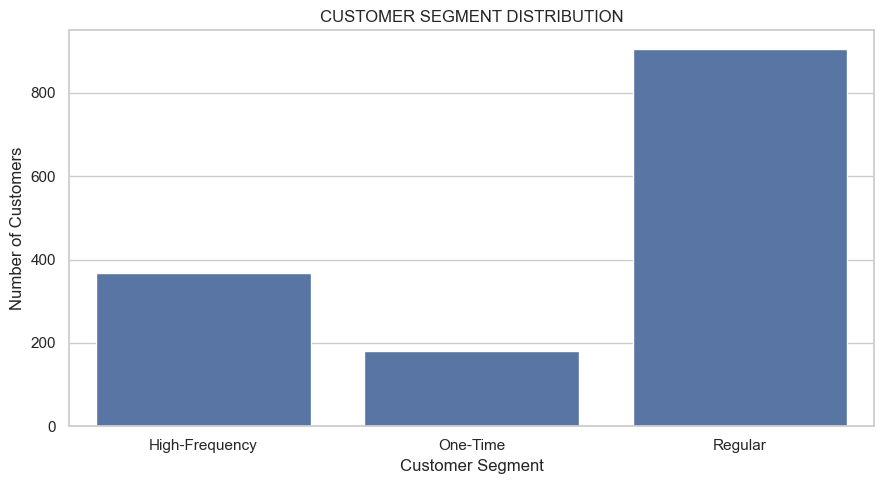

In [5]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_summary,
    x="segment",
    y="customers"
)

plt.title("CUSTOMER SEGMENT DISTRIBUTION")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig(
    f"{FIGURE_PATH}/customer_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


In [6]:
customer_revenue = (
    order_items
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .groupby("customer_id")["item_revenue"]
    .sum()
    .reset_index(name="total_revenue")
    .sort_values("total_revenue", ascending=False)
)

top_customers = customer_revenue.head(10)
top_customers


,customer_id,total_revenue
1398,C1447,1527.70
1028,C1065,1399.37
980,C1017,1272.65
1134,C1176,1175.32
1235,C1281,1169.58
1137,C1179,1145.86
1125,C1166,1128.45
1172,C1215,1124.42
461,C0482,1104.36
826,C0860,1085.66


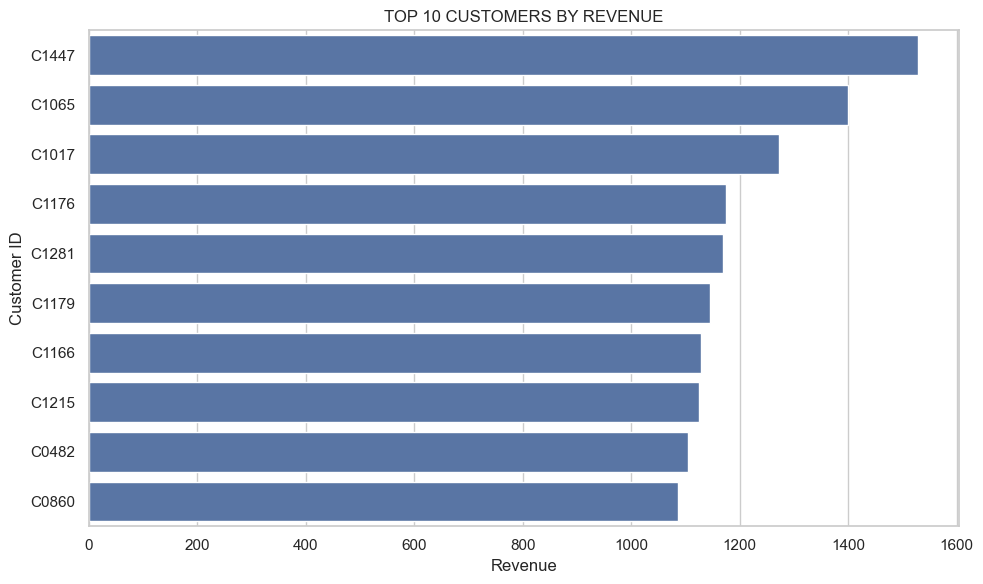

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_customers,
    y="customer_id",
    x="total_revenue"
)

plt.title("TOP 10 CUSTOMERS BY REVENUE")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.savefig(
    f"{FIGURE_PATH}/business_top_customers_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


In [8]:
restaurant_revenue = (
    order_items
    .merge(
        orders[["order_id", "restaurant_id"]],
        on="order_id",
        how="left"
    )
    .groupby("restaurant_id")["item_revenue"]
    .sum()
    .reset_index(name="total_revenue")
)

restaurant_orders = (
    orders.groupby("restaurant_id")
    .size()
    .reset_index(name="total_orders")
)

restaurant_delivery = (
    orders.groupby("restaurant_id")["delivery_time_minutes"]
    .mean()
    .reset_index(name="avg_delivery_time")
)

restaurant_performance = (
    restaurants
    .merge(restaurant_orders, on="restaurant_id", how="left")
    .merge(restaurant_revenue, on="restaurant_id", how="left")
    .merge(restaurant_delivery, on="restaurant_id", how="left")
)

restaurant_performance[
    ["total_orders", "total_revenue", "avg_delivery_time"]
] = restaurant_performance[
    ["total_orders", "total_revenue", "avg_delivery_time"]
].fillna(0)

restaurant_performance = restaurant_performance.sort_values(
    "total_revenue",
    ascending=False
)

restaurant_performance.head(10)


,restaurant_id,cuisine,city,rating,total_orders,total_revenue,avg_delivery_time
60,R061,Thai,Manchester,4.5,51,6908.29,54.235294
72,R073,Thai,Leeds,3.3,50,6817.47,57.500000
21,R022,Thai,Leeds,4.6,55,6754.09,57.690909
87,R088,American,Liverpool,4.6,54,6753.98,57.592593
95,R096,American,Bristol,4.0,54,6099.41,54.148148
59,R060,Indian,Manchester,3.8,56,6059.29,57.428571
114,R115,Chinese,Birmingham,5.0,51,6045.79,47.117647
73,R074,Indian,Birmingham,3.5,53,5968.25,53.377358
77,R078,Chinese,Bristol,4.3,51,5944.74,57.176471
89,R090,American,Birmingham,3.2,46,5921.60,54.500000


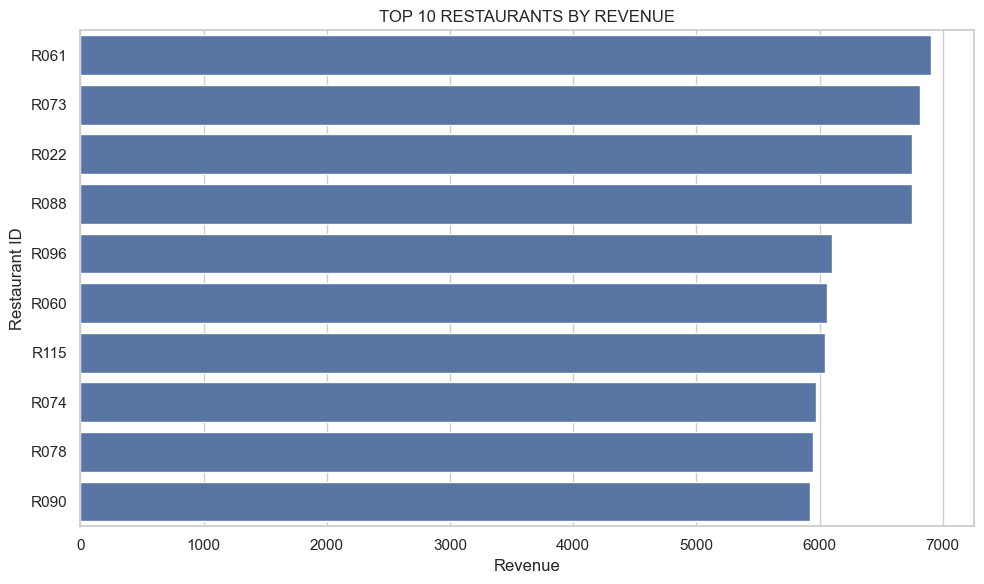

In [9]:
top_restaurants = restaurant_performance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_restaurants,
    y="restaurant_id",
    x="total_revenue"
)

plt.title("TOP 10 RESTAURANTS BY REVENUE")
plt.xlabel("Revenue")
plt.ylabel("Restaurant ID")

plt.tight_layout()
plt.savefig(
    f"{FIGURE_PATH}/business_top_restaurants_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


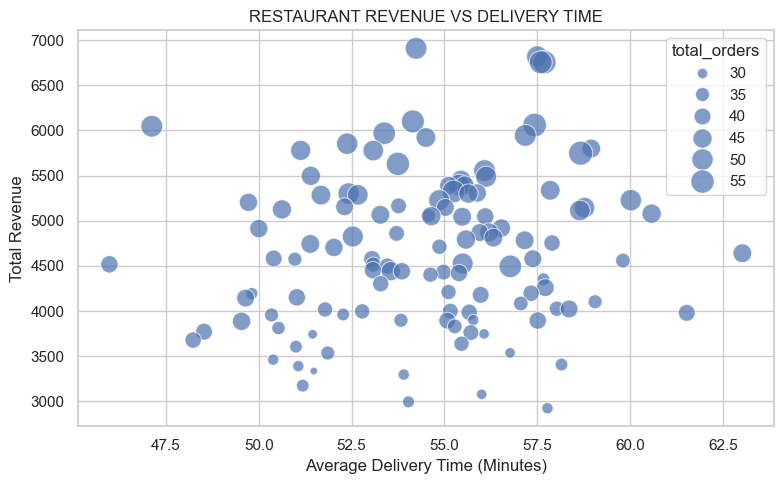

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=restaurant_performance,
    x="avg_delivery_time",
    y="total_revenue",
    size="total_orders",
    sizes=(30, 300),
    alpha=0.7
)

plt.title("RESTAURANT REVENUE VS DELIVERY TIME")
plt.xlabel("Average Delivery Time (Minutes)")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.savefig(
    f"{FIGURE_PATH}/restaurant_revenue_vs_delivery_time.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


In [11]:
order_revenue = (
    order_items
    .groupby("order_id")["item_revenue"]
    .sum()
    .reset_index(name="order_revenue")
)

order_revenue_summary = order_revenue["order_revenue"].describe()
order_revenue_summary


count    5000.000000
mean      112.101830
std        68.332823
min         5.090000
25%        57.847500
50%       102.910000
75%       156.642500
max       361.130000
Name: order_revenue, dtype: float64

In [12]:
monthly_revenue = (
    order_items
    .merge(
        orders[["order_id", "order_time"]],
        on="order_id",
        how="left"
    )
)

monthly_revenue["month"] = (
    monthly_revenue["order_time"]
    .dt.to_period("M")
)

monthly_revenue = (
    monthly_revenue
    .groupby("month")["item_revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["month"] = monthly_revenue["month"].astype(str)

peak_revenue_month = monthly_revenue.loc[
    monthly_revenue["item_revenue"].idxmax()
]

print("Highest Revenue Month:")
print(peak_revenue_month)


Highest Revenue Month:
month            2023-07
item_revenue    36348.99
Name: 6, dtype: object


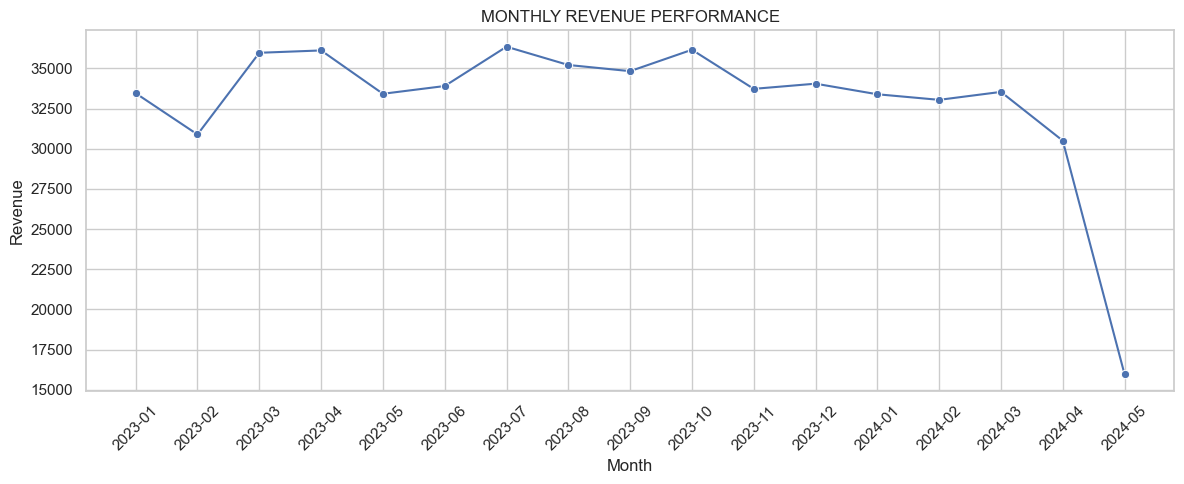

In [13]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_revenue,
    x="month",
    y="item_revenue",
    marker="o"
)

plt.title("MONTHLY REVENUE PERFORMANCE")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(
    f"{FIGURE_PATH}/business_monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


In [14]:
revenue_by_cuisine = (
    order_items
    .merge(
        orders[["order_id", "restaurant_id"]],
        on="order_id",
        how="left"
    )
    .merge(
        restaurants[["restaurant_id", "cuisine"]],
        on="restaurant_id",
        how="left"
    )
    .groupby("cuisine")["item_revenue"]
    .sum()
    .reset_index(name="total_revenue")
    .sort_values("total_revenue", ascending=False)
)

revenue_by_cuisine["revenue_share_pct"] = (
    revenue_by_cuisine["total_revenue"]
    / revenue_by_cuisine["total_revenue"].sum() * 100
)

revenue_by_cuisine


,cuisine,total_revenue,revenue_share_pct
5,Thai,127428.71,22.734457
2,Indian,102630.54,18.310235
0,American,90864.14,16.211000
4,Mexican,90060.25,16.067579
3,Italian,89963.60,16.050336
1,Chinese,59561.91,10.626394


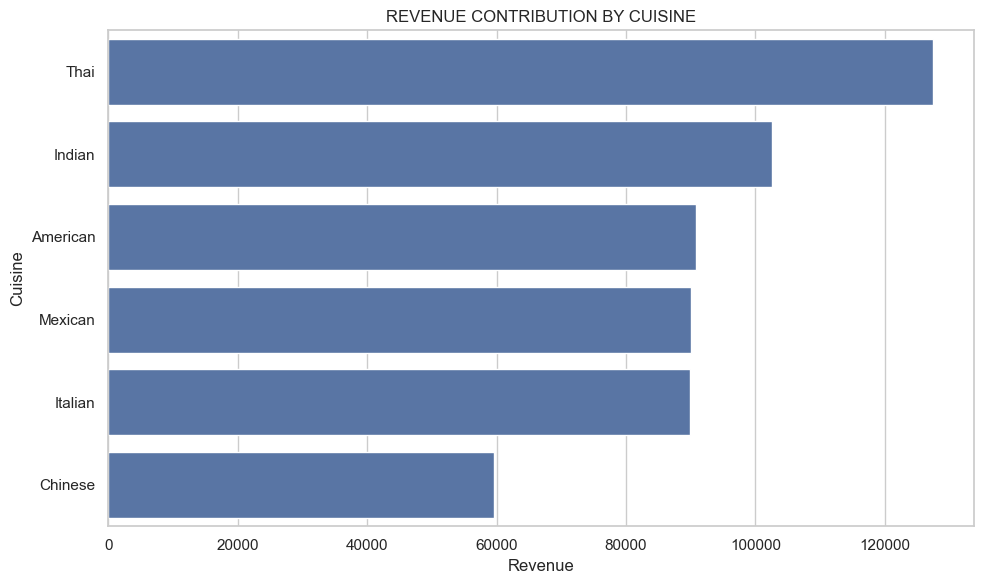

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=revenue_by_cuisine,
    y="cuisine",
    x="total_revenue"
)

plt.title("REVENUE CONTRIBUTION BY CUISINE")
plt.xlabel("Revenue")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.savefig(
    f"{FIGURE_PATH}/business_revenue_by_cuisine.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


In [16]:
delivery_summary = orders["delivery_time_minutes"].describe()

slowest_cities = (
    orders
    .merge(
        customers[["customer_id", "city"]],
        on="customer_id",
        how="left"
    )
    .groupby("city")["delivery_time_minutes"]
    .mean()
    .reset_index(name="avg_delivery_time")
    .sort_values("avg_delivery_time", ascending=False)
)

slowest_cities.head(10)


,city,avg_delivery_time
0,Birmingham,55.370138
1,Bristol,55.259645
3,Liverpool,55.226322
4,London,54.079800
5,Manchester,53.907692
2,Leeds,53.805654


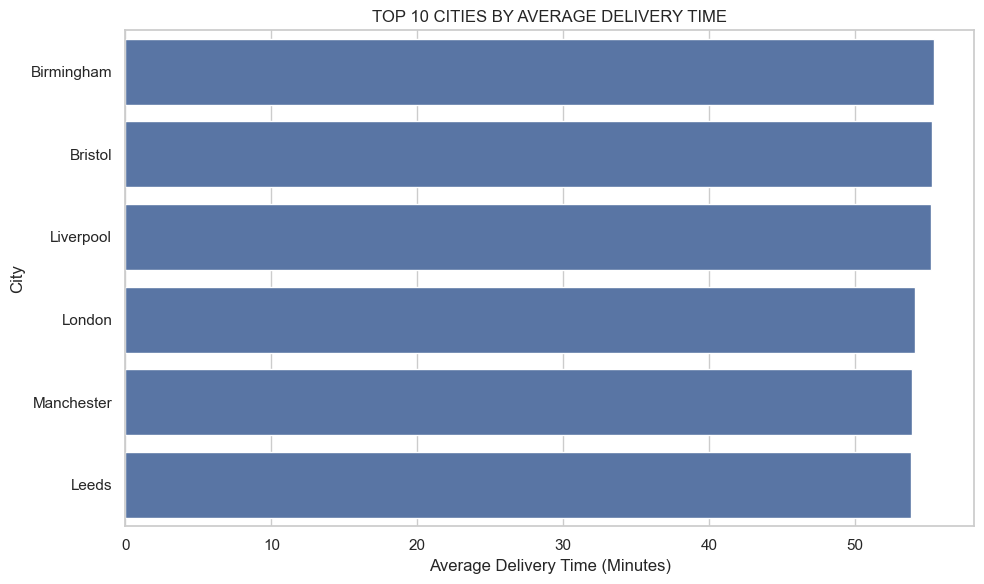

In [17]:
top_slow_cities = slowest_cities.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_slow_cities,
    y="city",
    x="avg_delivery_time"
)

plt.title("TOP 10 CITIES BY AVERAGE DELIVERY TIME")
plt.xlabel("Average Delivery Time (Minutes)")
plt.ylabel("City")

plt.tight_layout()
plt.savefig(
    f"{FIGURE_PATH}/business_delivery_time_by_city.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


In [18]:
item_business = (
    order_items
    .groupby("item_id")
    .agg(
        total_quantity=("quantity", "sum"),
        total_revenue=("item_revenue", "sum")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

top_items_business = item_business.head(10)
top_items_business


,item_id,total_quantity,total_revenue
269,M0270,90,3513.60
107,M0108,98,3470.18
180,M0181,87,3412.14
213,M0214,88,3375.68
119,M0120,90,3267.00
304,M0305,83,3180.56
338,M0339,79,3143.41
77,M0078,85,2986.90
152,M0153,73,2901.75
4,M0005,83,2881.76


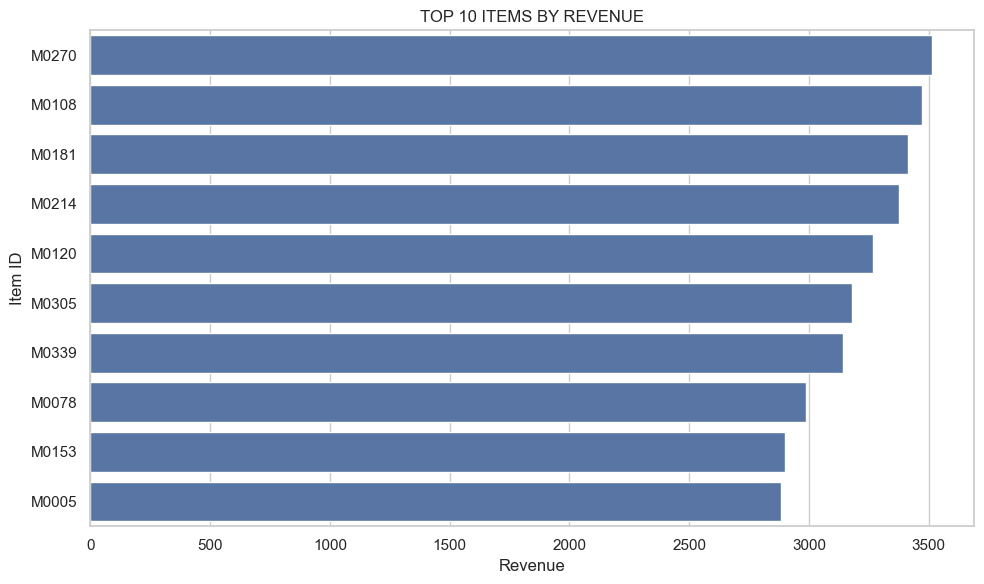

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_items_business,
    y="item_id",
    x="total_revenue"
)

plt.title("TOP 10 ITEMS BY REVENUE")
plt.xlabel("Revenue")
plt.ylabel("Item ID")

plt.tight_layout()
plt.savefig(
    f"{FIGURE_PATH}/business_top_items_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


In [20]:
# Quick business snapshot

print("BUSINESS SNAPSHOT")
print("=" * 50)

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ${aov:,.2f}")
print(f"Repeat Customer Rate: {repeat_customer_rate:.2f}%")
print(f"Revenue per Active Customer: ${revenue_per_active_customer:,.2f}")
print(f"Average Items per Order: {average_items_per_order:.2f}")
print(f"Average Delivery Time: {avg_delivery_time:.2f} minutes")


BUSINESS SNAPSHOT
Total Revenue: $560,509.15
Total Orders: 5,000
Average Order Value: $112.10
Repeat Customer Rate: 87.60%
Revenue per Active Customer: $386.03
Average Items per Order: 4.94
Average Delivery Time: 54.62 minutes
